# Proyecciones teóricas: todos los planos y años

Generalización autocontenida de `Proyecciones_teoricas.ipynb`. Descubre todos los Excel de
`Datos/Plano de Siembras` y `Datos/Curvas por variedad`, incluyendo subcarpetas anuales.
Procesa **todos los archivos con hoja Datos, incluidas sus versiones**, y señala la versión
seleccionada por año y semana (preferencia por «actualizado»). Las comparaciones de
inventario utilizan únicamente las versiones seleccionadas y fechas ISO completas.

Se conservan la homologación con maestros, la unión estricta de pilotos por ciclo,
la exclusión auditada de registros no utilizables y la curva original: promedio de
corte/plantas por variedad y edad, ventana anterior de 78 semanas, ajuste IQR y horizonte
de 10 semanas. No se imputan edades sin curva ni se convierten faltantes en cero.

**Estadísticas por edición anual:** cada plano usa los libros del mismo año de su carpeta,
con toda la historia que contienen, filtrada por fecha de corte anterior al plano.
No se concatenan las ediciones anuales para entrenar una misma curva: contienen historia
repetida. El año de edición y el año del corte son variables distintas. Esto evita usar
ediciones de años posteriores, pero los Excel no permiten reconstruir la fecha exacta
en que se publicó o corrigió cada observación; no es un backtest de disponibilidad real.

La ejecución se realiza por año para limitar memoria. Las bases completas se guardan en
Parquet por año en `resultados_todos_los_anios`; un Excel reúne los resúmenes y controles.
La función `cargar_resultado(anio, tabla)` permite consultar cualquier año sin cargar los demás.
Los Excel originales no se modifican. El notebook original conserva sus cálculos y añade su revisión explícita de variedades sin curva.

In [1]:
from pathlib import Path
from datetime import datetime
import gc
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from python_calamine import CalamineWorkbook



ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Datos').is_dir())
RUTA_PLANOS = ROOT / 'Datos' / 'Plano de Siembras'
RUTA_ESTADISTICAS = ROOT / 'Datos' / 'Curvas por variedad'
SALIDA = ROOT / 'Notebooks' / 'Proyecciones Teoricas Propias' / 'resultados_todos_los_anios'
SALIDA.mkdir(parents=True, exist_ok=True)
HORIZONTE = 10
VENTANA_CURVA_SEMANAS = 78
pd.set_option('display.max_rows', 24)
pd.set_option('display.max_columns', 24)
pd.set_option('display.max_colwidth', 65)
INICIO = datetime.now()

def registrar(mensaje):
    texto = f'{datetime.now():%H:%M:%S} | {mensaje}'
    print(texto, flush=True)
    with (SALIDA / 'ejecucion.log').open('a', encoding='utf-8') as f:
        f.write(texto + '\n')

(SALIDA / 'ejecucion.log').write_text('', encoding='utf-8')

def descubrir(carpeta, tipo):
    registros = []
    for p in sorted(carpeta.rglob('*')):
        if not p.is_file() or p.suffix.lower() not in {'.xlsx', '.xlsm', '.xls', '.xlsb'} or p.name.startswith('~$'):
            continue
        relativo = p.relative_to(carpeta)
        anios = [int(x) for x in relativo.parts[:-1] if re.fullmatch(r'(19|20)\d{2}', x)]
        assert len(anios) == 1, f'Año de carpeta ambiguo o ausente: {p}'
        semana = re.search(r'(?:Semana|Sem)\s*(\d+)', p.stem, re.I) if tipo == 'plano' else None
        if tipo == 'plano':
            assert semana, f'Semana no identificada: {p}'
        registros.append({'tipo': tipo, 'archivo': relativo.as_posix(), 'ruta': str(p),
                          'anio_archivo': anios[0], 'semana_plano': int(semana.group(1)) if semana else None,
                          'bytes': p.stat().st_size})
    return pd.DataFrame(registros)

inventario_archivos = pd.concat([descubrir(RUTA_PLANOS, 'plano'), descubrir(RUTA_ESTADISTICAS, 'estadistica')], ignore_index=True)
assert not inventario_archivos.duplicated(['tipo', 'archivo']).any()
ANIOS = sorted(inventario_archivos.loc[inventario_archivos.tipo.eq('plano'), 'anio_archivo'].unique())
assert ANIOS, 'No se encontraron planos.'
for anio in ANIOS:
    assert ((inventario_archivos.tipo == 'estadistica') & (inventario_archivos.anio_archivo == anio)).any(), f'Faltan estadísticas de {anio}'
display(inventario_archivos.groupby(['anio_archivo', 'tipo']).agg(archivos=('archivo', 'size'), bytes=('bytes', 'sum')))
registrar(f'Años: {ANIOS}; archivos inventariados: {len(inventario_archivos)}')
RECALCULAR_DESDE_EXCEL = False  # True reconstruye todos los años desde las fuentes.

archivos       bytes
anio_archivo tipo                             
2021         estadistica         4   228416952
             plano              52  1763543159
2022         estadistica         4   255684775
             plano              52  1834531361
2023         estadistica         4   223245763
             plano              52  1464607159
2024         estadistica         4   207415290
             plano              52   702184891
2025         estadistica         4   263082835
             plano              52   629705389
2026         estadistica         4   227668584
             plano              34   437852590

08:38:30 | Años: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]; archivos inventariados: 318


## 1. Maestros, fechas y homologación
Mismas reglas del notebook original: sin coincidencias aproximadas ni eliminación de registros inactivos.

Se distinguen códigos SQL duplicados de identidad comercial ambigua. Si producto, color y nombre normalizado determinan una única combinación del maestro, `clave_curva` identifica esa combinación y conserva la lista de IDs; `IdVariedad` permanece nulo cuando no es único. No se fusionan colores distintos ni se asigna un ID arbitrario. VERONICAS se homologa con VERONICA, conservando nombre de variedad exacto.

In [2]:
import numpy as np
import re
from datetime import date
import matplotlib.pyplot as plt

RUTA_MAESTROS = ROOT / 'Notebooks' / 'Extracción SQL' / 'Datos' / '01_maestros_y_geografia'
import json
CATALOGO=RUTA_MAESTROS/'Catalogo_analitico'
assert (CATALOGO/'maestro_variedades_integrado.parquet').exists(), 'Ejecutar primero 00_catalogo_variedades.ipynb'
maestro_productos=pd.read_parquet(CATALOGO/'productos.parquet')
maestro_colores=pd.read_parquet(CATALOGO/'colores.parquet')
maestro=pd.read_parquet(CATALOGO/'maestro_variedades_integrado.parquet')

def normalizar(s):
    return (s.astype('string').str.strip().str.upper().str.normalize('NFKD')
            .str.encode('ascii', errors='ignore').str.decode('ascii')
            .str.replace(r'\s+', ' ', regex=True).replace('', pd.NA))

def vacios(d):
    return d.replace(['','NULL','null','None','NONE','N/A','n/a','NA','na'], np.nan).replace(r'^\s*$', np.nan, regex=True)

def campo(d, *nombres):
    cols = dict(zip(normalizar(pd.Series(d.columns)), d.columns))
    for nombre in normalizar(pd.Series(nombres)):
        if nombre in cols:
            return d[cols[nombre]]
    return pd.Series(pd.NA, index=d.index, dtype='object')

def fechas(s):
    # No interpretar seriales Excel como nanosegundos desde 1970.
    numero = pd.to_numeric(s, errors='coerce')
    f = pd.to_datetime(s.where(numero.isna()), errors='coerce', format='mixed', dayfirst=True)
    serial = numero.between(20000, 80000)
    f.loc[serial] = pd.to_datetime(numero.loc[serial], unit='D', origin='1899-12-30')
    return f.where(f.between('1980-01-01','2100-12-31'))

def lunes_iso(anio, semana):
    # Una semana imposible (p. ej. 53 en ciertos años) se reporta, no se desplaza silenciosamente.
    pares = pd.DataFrame({'a':pd.to_numeric(anio, errors='coerce'), 's':pd.to_numeric(semana, errors='coerce')}).fillna(-1)
    def convertir(t):
        a,s=t
        try:
            if pd.isna(a) or pd.isna(s) or a != int(a) or s != int(s) or not 1980 <= a <= 2100: return pd.NaT
            return pd.Timestamp(date.fromisocalendar(int(a), int(s), 1))
        except ValueError:
            return pd.NaT
    mapa = {t:convertir(t) for t in pares.itertuples(index=False, name=None)}
    return pd.Series([mapa[t] for t in pares.itertuples(index=False, name=None)], index=anio.index, dtype='datetime64[ns]')

equivalencias=json.loads((CATALOGO/'equivalencias.json').read_text(encoding='utf-8'))
ALIAS_PRODUCTOS=equivalencias['productos']
ALIAS_COLORES=equivalencias['colores']
# Rosado y lila no se traducen por intuición: la variedad resuelta aporta su color oficial.
maestro['_var'] = normalizar(maestro.NomVariedad)
maestro['_prod'] = normalizar(maestro.NomProducto)
maestro['_color'] = normalizar(maestro.NomColor)
por_variedad = {k:g for k,g in maestro.groupby('_var')}
def mapa_unico(d, nombre, identificador):
    t=d.assign(k=normalizar(d[nombre]))
    t=t.loc[~t.k.duplicated(keep=False) & t.k.notna()]
    return t.set_index('k')[identificador].to_dict()
ids_producto = mapa_unico(maestro_productos,'NomProducto','IdProducto')
ids_color = mapa_unico(maestro_colores,'NomColor','IdColor')
nom_producto = dict(zip(normalizar(maestro_productos.NomProducto),maestro_productos.NomProducto))
nom_color = dict(zip(normalizar(maestro_colores.NomColor),maestro_colores.NomColor))

def homologar(d):
    d=d.copy()
    for c in ['producto','color','variedad']:d[c+'_original']=d[c]
    claves=pd.DataFrame({'_prod':normalizar(d.producto).replace(ALIAS_PRODUCTOS),
        '_color':normalizar(d.color).replace(ALIAS_COLORES),'_var':normalizar(d.variedad)})
    res=[]
    for prod,col,var in claves.fillna('').drop_duplicates().itertuples(index=False,name=None):
        candidatas=por_variedad.get(var,maestro.iloc[:0])
        if prod:candidatas=candidatas.loc[candidatas._prod.eq(prod)]
        inicial=len(candidatas)
        comerciales=candidatas[['_prod','_color','_var']].drop_duplicates()
        # Diferentes IDs no implican distintas identidades comerciales.
        if len(comerciales)>1 and col:
            candidatas=candidatas.loc[candidatas._color.eq(col)]
            comerciales=candidatas[['_prod','_color','_var']].drop_duplicates()
        r={'_prod':prod,'_color':col,'_var':var,
           'estado_maestro':'sin_coincidencia' if inicial==0 else 'ambiguo',
           'IdVariedad':np.nan,'IdProducto':ids_producto.get(prod,np.nan),'IdColor':ids_color.get(col,np.nan),
           'producto':nom_producto.get(prod,prod or pd.NA),'color':nom_color.get(col,col or pd.NA),
           'variedad':var or pd.NA,'conflicto_color':False,'clave_curva':pd.NA,
           'ids_maestro_equivalentes':'','identidad_comercial_sin_id_unico':False}
        if len(comerciales)==1:
            identidad=comerciales.iloc[0]
            ids=sorted(candidatas.IdVariedad.unique())
            unico=len(ids)==1
            # No escoger arbitrariamente un código SQL cuando existen varios.
            r.update(IdVariedad=ids[0] if unico else np.nan,
                IdProducto=candidatas.IdProducto.iloc[0] if candidatas.IdProducto.nunique()==1 else np.nan,
                IdColor=candidatas.IdColor.iloc[0] if candidatas.IdColor.nunique()==1 else np.nan,
                producto=nom_producto.get(identidad._prod,identidad._prod),
                color=nom_color.get(identidad._color,identidad._color),
                variedad=candidatas.NomVariedad.iloc[0] if unico else identidad._var,
                estado_maestro='unico' if unico else 'comercial_unica_ids_multiples',
                conflicto_color=bool(col and col!=identidad._color),
                clave_curva='COMERCIAL|'+identidad._prod+'|'+identidad._color+'|'+identidad._var,
                ids_maestro_equivalentes=';'.join(str(int(x)) for x in ids),
                identidad_comercial_sin_id_unico=not unico)
        res.append(r)
    m=claves.fillna('').merge(pd.DataFrame(res),on=['_prod','_color','_var'],how='left',validate='many_to_one')
    for c in ['IdVariedad','IdProducto','IdColor','producto','color','variedad','estado_maestro','conflicto_color','clave_curva','ids_maestro_equivalentes','identidad_comercial_sin_id_unico']:
        d[c]=m[c].to_numpy()
    return d


## 2. Lectura y limpieza de planos
El año procede de la carpeta, la semana del nombre y la fecha de referencia es el lunes ISO.
Las columnas descriptivas ausentes se conservan como nulas ; se exige que
existan finca, invernadero, cama, producto, variedad, plantas y fecha de siembra.
Solo se retiran filas con PLANTAS vacías. Las cantidades inválidas se señalan.
El identificador de archivo incluye su carpeta, por lo que una semana de años diferentes nunca se sobrescribe.

In [3]:
# Columnas seleccionadas

columnas = [
    "C",
    "COD-FINCA",
    "FINCA",
    "COD-INVERNADERO",
    "INVERNADERO",
    "SECTOR",
    "CAMA",
    "NRO CAMA",
    "PRODUCTO",
    "COLOR",
    "VARIEDAD",
    "PLANTAS",
    "FECHA_SIEMBRA",
    "SEM_SIEMBRA",
    "AÑOSIEM",
    "SUSTRATO",
    "PROVEEDOR"
]

renombrar_planos = {'C':'c','COD-FINCA':'codigo_finca','FINCA':'finca',
    'COD-INVERNADERO':'codigo_invernadero','INVERNADERO':'invernadero','SECTOR':'sector',
    'CAMA':'cama','NRO CAMA':'numero_cama','PRODUCTO':'producto','COLOR':'color','VARIEDAD':'variedad',
    'PLANTAS':'plantas','FECHA_SIEMBRA':'fecha_siembra','SEM_SIEMBRA':'semana_siembra',
    'AÑOSIEM':'anio_siembra','SUSTRATO':'sustrato','PROVEEDOR':'proveedor'}

In [4]:
def leer_planos(anio):
    partes, retiradas, controles = [], [], []
    obligatorias = {'FINCA', 'INVERNADERO', 'CAMA', 'PRODUCTO', 'VARIEDAD', 'PLANTAS', 'FECHA_SIEMBRA'}
    entradas = inventario_archivos.loc[inventario_archivos.tipo.eq('plano') & inventario_archivos.anio_archivo.eq(anio)]
    for entrada in entradas.itertuples(index=False):
        try:
            libro = pd.ExcelFile(CalamineWorkbook.from_path(entrada.ruta), engine='calamine')
            hojas = [h for h in libro.sheet_names if h.strip().lower() == 'datos']
            if len(hojas) != 1:
                controles.append({'archivo': entrada.archivo, 'anio_plano': anio, 'semana_plano': int(entrada.semana_plano),
                                  'fecha_plano': pd.Timestamp(date.fromisocalendar(int(anio), int(entrada.semana_plano), 1)),
                                  'filas_originales': np.nan, 'sin_plantas': np.nan, 'filas_conservadas': 0,
                                  'columnas_ausentes': 'HOJA_DATOS_AUSENTE', 'plantas_fuente': np.nan, 'plantas_limpias': np.nan,
                                  'estado_lectura': 'no_procesable_hoja_datos_ausente'})
                libro.close()
                registrar(f'Plano omitido por calidad: {entrada.archivo}: no tiene hoja Datos')
                continue
            p = pd.read_excel(libro, sheet_name=hojas[0], header=1, dtype=object, keep_default_na=False,
                              usecols=lambda c: str(c).strip() in columnas)
            libro.close()
        except Exception as exc:
            controles.append({'archivo': entrada.archivo, 'anio_plano': anio, 'semana_plano': int(entrada.semana_plano),
                              'fecha_plano': pd.Timestamp(date.fromisocalendar(int(anio), int(entrada.semana_plano), 1)),
                              'filas_originales': np.nan, 'sin_plantas': np.nan, 'filas_conservadas': 0,
                              'columnas_ausentes': 'ERROR_LECTURA', 'plantas_fuente': np.nan, 'plantas_limpias': np.nan,
                              'estado_lectura': f'no_procesable:{type(exc).__name__}'})
            registrar(f'Plano omitido por error de lectura: {entrada.archivo}: {exc}')
            continue
        p.columns = p.columns.str.strip()
        faltantes = sorted(set(columnas) - set(p.columns))
        assert obligatorias.issubset(p.columns), f'Faltan columnas esenciales: {entrada.archivo}: {faltantes}'
        p = p.reindex(columns=columnas).replace(r'^\s*$', np.nan, regex=True)
        p['fila_excel'] = np.arange(3, len(p) + 3)
        p['archivo'] = entrada.archivo
        p['semana_plano'] = int(entrada.semana_plano)
        p['anio_plano'] = int(anio)
        p['fecha_plano'] = pd.Timestamp(date.fromisocalendar(int(anio), int(entrada.semana_plano), 1))
        sin_plantas = p.PLANTAS.isna()
        total_fuente = pd.to_numeric(p.PLANTAS, errors='coerce').sum(min_count=1)
        retiradas.append(p.loc[sin_plantas].rename(columns=renombrar_planos))
        control = {'archivo': entrada.archivo, 'anio_plano': anio, 'semana_plano': int(entrada.semana_plano),
                   'fecha_plano': p.fecha_plano.iloc[0], 'filas_originales': len(p),
                   'sin_plantas': int(sin_plantas.sum()), 'filas_conservadas': int((~sin_plantas).sum()),
                   'columnas_ausentes': ', '.join(faltantes), 'plantas_fuente': total_fuente}
        p = p.loc[~sin_plantas].rename(columns=renombrar_planos).copy()
        p['plantas_original'] = p.plantas
        p['plantas'] = pd.to_numeric(p.plantas, errors='coerce')
        for c in ['semana_siembra', 'anio_siembra']:
            p[c] = pd.to_numeric(p[c], errors='coerce')
        p['fecha_siembra_original'] = p.fecha_siembra
        p['fecha_siembra'] = fechas(p.fecha_siembra)
        for c in ['finca', 'invernadero', 'cama', 'numero_cama', 'codigo_finca', 'codigo_invernadero']:
            p[c] = normalizar(p[c]).str.replace(r'\.0$', '', regex=True)
        p['cantidad_invalida'] = p.plantas.isna() | p.plantas.lt(0)
        lunes_siembra = p.fecha_siembra - pd.to_timedelta(p.fecha_siembra.dt.dayofweek, unit='D')
        p['edad_plano'] = np.floor((p.fecha_plano - lunes_siembra).dt.days / 7)
        control['plantas_limpias'] = p.plantas.sum(min_count=1)
        assert np.isclose(total_fuente, control['plantas_limpias'], equal_nan=True), entrada.archivo
        controles.append(control)
        partes.append(p)
        registrar(f'Plano leído: {entrada.archivo}: {len(p):,} filas conservadas')
    completo = homologar(pd.concat(partes, ignore_index=True))
    seleccion = []
    for (a, s), g in entradas.groupby(['anio_archivo', 'semana_plano']):
        elegible = g if len(g) == 1 else g.loc[g.archivo.str.contains('actualizado', case=False)]
        assert len(elegible) == 1, f'Revisar versiones {a}-{s}: {g.archivo.tolist()}'
        seleccion.append({'anio_plano': int(a), 'semana_plano': int(s), 'archivo': elegible.archivo.iloc[0],
                          'criterio': 'archivo único' if len(g) == 1 else 'marcado actualizado'})
    seleccion = pd.DataFrame(seleccion)
    completo['version_seleccionada'] = completo.archivo.isin(seleccion.archivo)
    completo['llave_repetida'] = completo.duplicated(['archivo', 'finca', 'invernadero', 'cama', 'variedad', 'fecha_siembra'], keep=False)
    return completo, pd.concat(retiradas, ignore_index=True), pd.DataFrame(controles), seleccion

## 3. Estadísticas y camas piloto por edición anual
Se detecta el encabezado de Camas Piloto en las primeras filas, incluido el formato antiguo.
«Mini Clavel» y «Miniclavel» se reconocen como el mismo producto. La unión conserva el
archivo anual en la llave y no mezcla pilotos de libros diferentes. Las fechas de corte
históricas de cada edición se conservan; solo la construcción de curvas filtra la ventana.

**Corrección de calidad:** las copias de pilotos idénticas en todos sus atributos, excepto fila e identificador técnico, se consultan como una sola referencia. Se preservan los registros originales y todas las ambigüedades con diferencias reales. La auditoría autocontenida `Auditoria_calidad_curvas.ipynb` documenta la recuperación y reconstruye los resultados históricos afectados.

In [5]:
def producto_libro(archivo):
    if 'miniclavel' in re.sub(r'[^a-z]', '', archivo.lower()): return 'MINICARNATION'
    if 'Clavel' in archivo: return 'CARNATION'
    if 'Green Ball' in archivo: return 'GREEN BALL'
    return pd.NA

def preparar_pilotos(d, archivo):
    d=vacios(d)
    return pd.DataFrame({'archivo':archivo,'fila_excel':d.fila_excel,
        'referencia':campo(d,'Referencia'),'producto':producto_libro(archivo),
        'color':campo(d,'Color'),'variedad':campo(d,'Variedad'),
        'bloque':campo(d,'No. Bloque'),'cama':campo(d,'No. Cama'),
        'fecha_siembra':fechas(campo(d,'Fecha de Siembra')),
        'semana_siembra':pd.to_numeric(campo(d,'Sem Siembra'),errors='coerce'),
        'anio_siembra':pd.to_numeric(campo(d,'Año Siembra'),errors='coerce'),
        'plantas':pd.to_numeric(campo(d,'No. Plantas'),errors='coerce'),
        'plantas_original':campo(d,'No. Plantas'),
        'sustrato':campo(d,'Sustrato','Tipo de sustrato'),'casa_breeder':campo(d,'Casa','Breeder')})

def preparar_estadisticas(d, archivo):
    d=vacios(d)
    producto=campo(d,'PRODUCTO').fillna(producto_libro(archivo)) if not pd.isna(producto_libro(archivo)) else campo(d,'PRODUCTO')
    return pd.DataFrame({'archivo':archivo,'fila_excel':d.fila_excel,
        'referencia':campo(d,'CAMA PILOTO','CODIGO'),'producto':producto,
        'color':campo(d,'Color'),'variedad':campo(d,'Variedad'),
        'anio_corte':pd.to_numeric(campo(d,'Año Corte'),errors='coerce'),
        'semana_corte':pd.to_numeric(campo(d,'SEM Corte','Semana'),errors='coerce'),
        'corte':pd.to_numeric(campo(d,'CORTE SEMANAL'),errors='coerce'),
        'corte_original':campo(d,'CORTE SEMANAL'),
        'edad_original':pd.to_numeric(campo(d,'Edad'),errors='coerce'),
        'fecha_siembra':fechas(campo(d,'Fecha de Siembra')),
        'semana_siembra':pd.to_numeric(campo(d,'Semana de Siembra','SEMANA SIEMBRA'),errors='coerce'),
        'anio_siembra':pd.to_numeric(campo(d,'Año de Siembra','AÑO SIEMBRA'),errors='coerce'),
        'sustrato':campo(d,'Sustrato'),'casa_breeder':campo(d,'CASA','Breeder')})

In [6]:
def leer_estadisticas(anio):
    estadisticas_crudas, camas_piloto_crudas = {}, {}
    entradas = inventario_archivos.loc[inventario_archivos.tipo.eq('estadistica') & inventario_archivos.anio_archivo.eq(anio)]
    for entrada in entradas.itertuples(index=False):
        with pd.ExcelFile(CalamineWorkbook.from_path(entrada.ruta), engine='calamine') as libro:
            hojas = [h for h in libro.sheet_names if h.strip().lower() in ('base de datos', 'corte semanal')]
            assert len(hojas) == 1, f'Revisar detalle de {entrada.archivo}: {hojas}'
            es = pd.read_excel(libro, sheet_name=hojas[0], header=0, dtype=object, keep_default_na=False)
            es['fila_excel'] = np.arange(2, len(es) + 2)
            estadisticas_crudas[entrada.archivo] = es
            hp = [h for h in libro.sheet_names if h.strip().lower() == 'camas piloto']
            assert len(hp) == 1, f'Falta hoja Camas Piloto: {entrada.archivo}'
            muestra = pd.read_excel(libro, sheet_name=hp[0], header=None, nrows=5, dtype=object)
            candidatos = [i for i, fila in muestra.iterrows() if {'REFERENCIA', 'VARIEDAD', 'NO. PLANTAS'}.issubset(set(normalizar(fila).dropna()))]
            assert len(candidatos) == 1, f'Encabezado de pilotos ambiguo: {entrada.archivo}'
            header = candidatos[0]
            cp = pd.read_excel(libro, sheet_name=hp[0], header=header, dtype=object, keep_default_na=False)
            cp['fila_excel'] = np.arange(header + 2, len(cp) + header + 2)
            camas_piloto_crudas[entrada.archivo] = cp
        registrar(f'Estadísticas leídas: {entrada.archivo}: {len(es):,} cortes, {len(cp):,} pilotos')
    pilotos, estadisticas, estructura=[] , [], []

    for archivo in estadisticas_crudas:
        cp=camas_piloto_crudas[archivo]
        es=estadisticas_crudas[archivo]
        for familia,d,lista in [('pilotos',preparar_pilotos(cp,archivo),pilotos),
                                ('estadisticas',preparar_estadisticas(es,archivo),estadisticas)]:
            cantidad='plantas_original' if familia=='pilotos' else 'corte_original'
            plantilla=d[['referencia','variedad',cantidad]].isna().all(axis=1)
            estructura.append({'archivo':archivo,'familia':familia,'filas':len(d),'plantilla':int(plantilla.sum())})
            lista.append(d.loc[~plantilla].copy())
    df_camas_piloto=homologar(pd.concat(pilotos,ignore_index=True))
    df_estadisticas_base=homologar(pd.concat(estadisticas,ignore_index=True))
    for d in [df_camas_piloto,df_estadisticas_base]:
        d['variedad_llave']=normalizar(d.variedad)
        # Se conserva la referencia completa: no unir sólo por número de cama.
        d['referencia_llave']=normalizar(d.referencia).str.replace(r'\s*-\s*','-',regex=True)
        d['semana_siembra']=d.semana_siembra.where(d.semana_siembra.lt(100),d.semana_siembra.mod(100))
        d['fecha_semana_siembra']=lunes_iso(d.anio_siembra,d.semana_siembra)
    df_camas_piloto['id_piloto']=np.arange(len(df_camas_piloto))
    df_estadisticas_base['id_estadistica']=np.arange(len(df_estadisticas_base))
    df_estadisticas_base['fecha_corte']=lunes_iso(df_estadisticas_base.anio_corte,df_estadisticas_base.semana_corte)
    display(pd.DataFrame(estructura))

    llaves=['archivo','variedad_llave','referencia_llave']
    e=df_estadisticas_base
    p=df_camas_piloto
    completa=e[llaves].notna().all(axis=1)
    # Colapsar sólo copias idénticas en TODOS los atributos, salvo fila e ID técnico.
    # Los registros originales se conservan en camas_piloto; no sumar ni borrar cortes.
    atributos_identidad=[c for c in p.columns if c not in ['id_piloto','fila_excel']]
    pderecha=p.loc[p[llaves].notna().all(axis=1)].drop_duplicates(atributos_identidad)
    campos_ciclo=['fecha_siembra','anio_siembra','semana_siembra']
    candidatas=e.loc[completa,['id_estadistica','fecha_corte']+llaves+campos_ciclo].merge(
        pderecha[llaves+campos_ciclo+['id_piloto']],on=llaves,how='inner',suffixes=('_est','_pil'))
    cantidad_inicial=candidatas.groupby('id_estadistica').size()
    tiene_fecha=candidatas.fecha_siembra_est.notna()
    tiene_semana=(candidatas.anio_siembra_est.between(1980,2100) & candidatas.semana_siembra_est.between(1,53))
    compatible_fecha=candidatas.fecha_siembra_est.eq(candidatas.fecha_siembra_pil)
    compatible_semana=(candidatas.anio_siembra_est.eq(candidatas.anio_siembra_pil) &
                        candidatas.semana_siembra_est.eq(candidatas.semana_siembra_pil))
    # No aceptar una siembra posterior a la semana del corte; permite días dentro de esa semana.
    temporal=candidatas.fecha_siembra_pil.isna() | candidatas.fecha_corte.isna() | (
        candidatas.fecha_siembra_pil.le(candidatas.fecha_corte+pd.Timedelta(days=6)))
    compatible=np.where(tiene_fecha,compatible_fecha,np.where(tiene_semana,compatible_semana,True)) & temporal
    candidatas_validas=candidatas.loc[compatible].copy()
    n=candidatas_validas.groupby('id_estadistica').size()
    unicas=candidatas_validas.loc[candidatas_validas.id_estadistica.map(n).eq(1),['id_estadistica','id_piloto']]
    resultado=e.merge(unicas,on='id_estadistica',how='left',validate='one_to_one')
    resultado['candidatas_iniciales']=resultado.id_estadistica.map(cantidad_inicial).fillna(0).astype(int)
    resultado['candidatas_compatibles']=resultado.id_estadistica.map(n).fillna(0).astype(int)
    resultado['estado_union']=np.select([
        ~completa.to_numpy(),resultado.candidatas_iniciales.eq(0),resultado.candidatas_compatibles.eq(0),
        resultado.candidatas_compatibles.gt(1)],
        ['llave_incompleta','sin_pareja','conflicto_ciclo','ambigua'],default='unica')
    atributos=['id_piloto','fila_excel','plantas','fecha_siembra','anio_siembra','semana_siembra','sustrato','casa_breeder']
    resultado=resultado.merge(p[atributos],on='id_piloto',how='left',suffixes=('_est','_pil'),validate='many_to_one')
    for c in ['fecha_siembra','anio_siembra','semana_siembra','sustrato','casa_breeder']:
        resultado['conflicto_'+c]=(resultado[c+'_est'].notna() & resultado[c+'_pil'].notna() &
                                  normalizar(resultado[c+'_est']).ne(normalizar(resultado[c+'_pil'])).fillna(False))
        resultado[c]=resultado[c+'_pil'].combine_first(resultado[c+'_est'])
        resultado['origen_'+c]=np.select([resultado[c+'_pil'].notna(),resultado[c+'_est'].notna()],['piloto','estadistica'],default='faltante')
    resultado['fecha_semana_siembra']=resultado.fecha_siembra-pd.to_timedelta(resultado.fecha_siembra.dt.dayofweek,unit='D')
    resultado['fecha_semana_siembra']=resultado.fecha_semana_siembra.fillna(lunes_iso(resultado.anio_siembra,resultado.semana_siembra))
    resultado['edad']=((resultado.fecha_corte-resultado.fecha_semana_siembra).dt.days//7).astype('Int64')
    resultado['flores_x_planta']=resultado.corte.div(resultado.plantas.where(resultado.plantas.gt(0)))
    resultado['diferencia_edad']=resultado.edad-resultado.edad_original
    llave_corte=['archivo','referencia_llave','variedad_llave','fecha_semana_siembra','fecha_corte']
    resultado['corte_repetido']=resultado.duplicated(llave_corte,keep=False)
    df_estadisticas_completo=resultado
    assert len(resultado)==len(e) and resultado.id_estadistica.is_unique
    reporte_uniones=resultado.groupby(['archivo','estado_union']).agg(filas=('id_estadistica','size'),
        corte_reportado=('corte',lambda s:s.sum(min_count=1))).reset_index()
    reporte_uniones['porcentaje_filas']=100*reporte_uniones.filas/reporte_uniones.groupby('archivo').filas.transform('sum')
    uniones_pendientes=resultado.loc[resultado.estado_union.ne('unica')].copy()
    pilotos_llave_repetida=p.loc[p.duplicated(llaves,keep=False)].sort_values(llaves)
    display(reporte_uniones.round(2))
    display(uniones_pendientes[['archivo','fila_excel_est','referencia','variedad','estado_union','candidatas_iniciales']].head(20))
    print('No se eliminan uniones fallidas: revisar uniones_pendientes antes de decidir descartes.')

    r=df_estadisticas_completo
    motivos_eda=pd.DataFrame({
        'union_no_unica':r.estado_union.ne('unica'),'identidad_comercial_sin_resolver':r.clave_curva.isna(),
        'plantas_invalidas':~r.plantas.gt(0),'corte_invalido':~r.corte.ge(0),
        'fecha_corte_invalida':r.fecha_corte.isna(),'edad_invalida':r.edad.isna() | r.edad.lt(0),
        'corte_repetido':r.corte_repetido}).fillna(True)
    control_eda_estadisticas=motivos_eda.sum().rename('filas_afectadas').to_frame()
    control_eda_estadisticas['porcentaje']=100*control_eda_estadisticas.filas_afectadas/len(r)
    df_estadisticas_eda=r.loc[~motivos_eda.any(axis=1)].copy()

    df_estadisticas_eda['anio_edicion'] = int(anio)
    df_estadisticas_completo['anio_edicion'] = int(anio)
    df_camas_piloto['anio_edicion'] = int(anio)
    reporte_uniones['anio_edicion'] = int(anio)
    control_eda_estadisticas = control_eda_estadisticas.reset_index(names='motivo').assign(anio_edicion=int(anio))
    return df_estadisticas_eda, df_estadisticas_completo, df_camas_piloto, reporte_uniones, control_eda_estadisticas

## 4. Proyección de cada archivo a diez semanas
La curva se calcula una sola vez para cada fecha de plano y sirve a todas las versiones
de esa fecha. Conserva los IDs homologados; una variedad ambigua no se resuelve tomando
arbitrariamente la primera del maestro. Los agregados son producción **parcial** cuando
hay plantas sin cobertura. Las curvas y sus cantidades de observaciones se exportan
para poder revisar cada proyección. IQR se calcula exclusivamente dentro de la ventana.

In [7]:
def proyectar(planos, estadisticas):
    est = estadisticas.copy()
    est['_r'] = est.corte / est.plantas
    assert est.plantas.gt(0).all() and est.corte.ge(0).all() and est.edad.ge(0).all()
    assert np.isfinite(est['_r']).all()
    coh = ['archivo', 'anio_plano', 'semana_plano', 'fecha_plano', 'version_seleccionada',
           'finca', 'producto', 'color', 'variedad', 'clave_curva', 'fecha_siembra']
    pp = planos.assign(_pv=planos.plantas.where(planos.plantas.ge(0)))
    cohortes = pp.groupby(coh, dropna=False, as_index=False).agg(
        plantas=('_pv', lambda s: s.sum(min_count=1)), plantas_invalidas=('cantidad_invalida', 'any'))
    salida, auditoria, curvas = [], [], []
    for fecha, c in cohortes.groupby('fecha_plano', sort=True):
        hist = est.loc[est.fecha_corte.ge(fecha - pd.Timedelta(weeks=VENTANA_CURVA_SEMANAS)) & est.fecha_corte.lt(fecha)].copy()
        assert hist.empty or hist.fecha_corte.max() < fecha
        if not hist.empty:
            gh = hist.groupby(['clave_curva', 'edad'])['_r']
            # Cuantiles vectorizados: misma regla IQR que el original, sin un lambda por grupo.
            q = gh.quantile([.25, .75]).unstack().rename(columns={.25: 'q1', .75: 'q3'})
            q['n'] = gh.size()
            hist = hist.join(q, on=['clave_curva', 'edad'], validate='many_to_one')
            li, ls = hist.q1 - 1.5*(hist.q3-hist.q1), hist.q3 + 1.5*(hist.q3-hist.q1)
            atipico = hist.n.ge(4) & (hist['_r'].lt(li) | hist['_r'].gt(ls))
            hist['_r_curva'] = hist['_r'].where(~atipico, hist['_r'].clip(lower=li, upper=ls))
        else:
            atipico = pd.Series(False, index=hist.index)
            hist['_r_curva'] = hist['_r']
        auditoria.append({'anio_plano': int(c.anio_plano.iloc[0]), 'fecha_plano': fecha,
                          'inicio_ventana': fecha - pd.Timedelta(weeks=VENTANA_CURVA_SEMANAS),
                          'max_fecha_corte': hist.fecha_corte.max(), 'observaciones_historicas': len(hist),
                          'puntos_limitados_iqr': int(atipico.sum())})
        cv = hist.groupby(['clave_curva', 'edad'], as_index=False).agg(
            rendimiento_curva=('_r_curva', 'mean'), n_observaciones=('_r', 'size'),
            n_camas=('id_piloto', 'nunique'))
        curvas.append(cv.assign(fecha_plano=fecha, anio_edicion=int(c.anio_plano.iloc[0])))
        ids = set(cv.clave_curva)
        lunes = c.fecha_siembra - pd.to_timedelta(c.fecha_siembra.dt.dayofweek, unit='D')
        for h in range(1, HORIZONTE + 1):
            obj = fecha + pd.Timedelta(weeks=h)
            o = c.copy()
            o['edad'] = ((obj - lunes).dt.days // 7).astype('Int64')
            o = o.merge(cv, on=['clave_curva', 'edad'], how='left', validate='many_to_one')
            o['semana_proyeccion'] = obj
            o['horizonte'] = h
            o['estado'] = np.select([
                o.plantas_invalidas, o.fecha_siembra.isna(), o.edad.lt(0).fillna(False),
                o.clave_curva.isna(), ~o.clave_curva.isin(ids), o.rendimiento_curva.notna()],
                ['plantas_invalidas', 'sin_fecha_siembra', 'siembra_posterior',
                 'sin_variedad_maestra', 'sin_historia_variedad', 'proyectada'], default='edad_fuera_de_curva')
            o['produccion_teorica'] = np.where(o.estado.eq('proyectada'), o.plantas * o.rendimiento_curva,
                                              np.where(o.estado.eq('siembra_posterior'), 0., np.nan))
            salida.append(o)
        registrar(f'Curvas y proyecciones {fecha:%Y-%m-%d}: {len(hist):,} observaciones históricas')
    proy = pd.concat(salida, ignore_index=True).rename(columns={'archivo': 'plano'})
    assert not proy.duplicated(['plano', 'horizonte', 'finca', 'producto', 'color', 'variedad', 'clave_curva', 'fecha_siembra']).any()
    assert proy.groupby('plano').horizonte.nunique().eq(HORIZONTE).all()
    ok = proy.estado.eq('proyectada')
    assert np.allclose(proy.loc[ok, 'produccion_teorica'], proy.loc[ok, 'plantas'] * proy.loc[ok, 'rendimiento_curva'])
    return proy, pd.DataFrame(auditoria), pd.concat(curvas, ignore_index=True)

## 5. Resumen y almacenamiento

Se resume por plano y semana objetivo, manteniendo cobertura y bandera de producción parcial. No se suman existencias entre snapshots.

In [8]:
def guardar_parquet(d, nombre, anio=None):
    import pyarrow.parquet as pq
    carpeta = SALIDA if anio is None else SALIDA / str(anio)
    carpeta.mkdir(parents=True, exist_ok=True)
    destino = carpeta / f'{nombre}.parquet'
    copia = d.copy()
    # Los originales mixtos se serializan como texto; columnas calculadas mantienen tipos.
    for col in copia.select_dtypes(include=['object']).columns:
        copia[col] = copia[col].astype('string')
    copia.to_parquet(destino, index=False)
    assert pq.read_metadata(destino).num_rows == len(d)
    return {'tabla': nombre, 'anio': anio, 'filas': len(d), 'archivo': str(destino.relative_to(SALIDA)), 'bytes': destino.stat().st_size}

def resumir_proyeccion(proy):
    d = proy.assign(plantas_proyectadas=proy.plantas.where(proy.estado.eq('proyectada'), 0),
                   plantas_sin_cobertura=proy.plantas.where(~proy.estado.isin(['proyectada', 'siembra_posterior']), 0),
                   filas_sin_cobertura=(~proy.estado.isin(['proyectada', 'siembra_posterior'])).astype(int))
    dims = ['plano', 'anio_plano', 'semana_plano', 'fecha_plano', 'version_seleccionada', 'semana_proyeccion', 'horizonte']
    r = d.groupby(dims, dropna=False, as_index=False).agg(
        produccion_teorica=('produccion_teorica', lambda s: s.sum(min_count=1)),
        plantas=('plantas', lambda s: s.sum(min_count=1)), plantas_proyectadas=('plantas_proyectadas', 'sum'),
        plantas_sin_cobertura=('plantas_sin_cobertura', 'sum'), filas_sin_cobertura=('filas_sin_cobertura', 'sum'),
        cohortes=('estado', 'size'))
    r['pct_plantas_proyectadas'] = 100 * r.plantas_proyectadas / r.plantas.where(r.plantas.gt(0))
    r['produccion_parcial'] = r.filas_sin_cobertura.gt(0)
    return r


## Ejecución anual y recuperación de resultados

Por defecto se leen los resultados anuales ya calculados. Cambiar `RECALCULAR_DESDE_EXCEL=True` para reconstruirlos desde los Excel. Se recorren todos los años en ambos modos. Los archivos sin hoja Datos se identifican explícitamente. No se calcula continuidad física de camas en este resumen.

In [9]:
resumenes_anuales, resumenes_proy, controles_planos, selecciones = [], [], [], []
inventarios_semanales, modelo_partes = [], []
for anio in ANIOS:
    registrar(f'Procesando resultados {anio}')
    carpeta = SALIDA / str(anio)
    if RECALCULAR_DESDE_EXCEL:
        u, a, camas, uniones, eda = leer_estadisticas(anio)
        p, retiradas, control, seleccion = leer_planos(anio)
        q, audit, curvas = proyectar(p, u)
        for nombre, tabla in [('estadisticas',u),('estadisticas_auditoria',a),('camas_piloto',camas),
            ('planos_todas_versiones',p),('planos',p.loc[p.version_seleccionada]),
            ('planos_filas_retiradas',retiradas),('proyecciones_teoricas',q),('curvas',curvas)]:
            guardar_parquet(tabla,nombre,anio)
    else:
        p = pd.read_parquet(carpeta/'planos_todas_versiones.parquet')
        retiradas = pd.read_parquet(carpeta/'planos_filas_retiradas.parquet')
        u = pd.read_parquet(carpeta/'estadisticas.parquet')
        q = pd.read_parquet(carpeta/'proyecciones_teoricas.parquet')
    assert set(q.plano) == set(p.archivo)
    assert q.groupby('plano').horizonte.nunique().eq(HORIZONTE).all()
    ok = q.estado.eq('proyectada')
    assert np.allclose(q.loc[ok,'produccion_teorica'],q.loc[ok,'plantas']*q.loc[ok,'rendimiento_curva'])
    control = inventario_archivos.loc[inventario_archivos.tipo.eq('plano') & inventario_archivos.anio_archivo.eq(anio),['archivo','anio_archivo']].copy()
    control['filas_conservadas'] = control.archivo.map(p.groupby('archivo').size()).fillna(0).astype(int)
    control['sin_plantas'] = control.archivo.map(retiradas.groupby('archivo').size()).fillna(0).astype(int)
    control['estado'] = np.where(control.filas_conservadas.gt(0),'procesado','sin_datos_procesables')
    # Verificar la causa de archivos ausentes incluso al recuperar resultados.
    for archivo in control.loc[control.filas_conservadas.eq(0),'archivo']:
        with pd.ExcelFile(RUTA_PLANOS/archivo,engine='calamine') as libro:
            assert not any(h.strip().lower()=='datos' for h in libro.sheet_names), archivo
        control.loc[control.archivo.eq(archivo),'estado']='sin_hoja_Datos'
    controles_planos.append(control)
    sel=p.loc[p.version_seleccionada]
    selecciones.append(sel[['archivo','anio_plano','semana_plano','fecha_plano']].drop_duplicates())
    resumenes_proy.append(resumir_proyeccion(q))
    inventarios_semanales.append(sel.groupby(['archivo','fecha_plano','finca','producto'],dropna=False,as_index=False).agg(plantas=('plantas','sum'),filas=('plantas','size')))
    resumenes_anuales.append(dict(anio=int(anio),archivos_planos=len(control),planos_procesados=p.archivo.nunique(),planos_seleccionados=sel.archivo.nunique(),filas_proyeccion=len(q),estadisticas_utilizables=len(u)))
    # Grano del modelo: una serie, plano y semana objetivo; no sumar snapshots.
    z=q.loc[q.version_seleccionada].copy()
    z['sin_cobertura']=~z.estado.isin(['proyectada','siembra_posterior'])
    dims=['plano','fecha_plano','finca','producto','color','variedad','semana_proyeccion']
    z=z.groupby(dims,dropna=False,as_index=False).agg(teoria=('produccion_teorica',lambda s:s.sum(min_count=1)),sin_cobertura=('sin_cobertura','sum'),cohortes=('estado','size'))
    modelo_partes.append(z)
    del p,q,u,retiradas,sel,z
    gc.collect()
resumen_anual=pd.DataFrame(resumenes_anuales)
proyeccion_semanal=pd.concat(resumenes_proy,ignore_index=True)
control_limpieza_planos=pd.concat(controles_planos,ignore_index=True)
seleccion_planos=pd.concat(selecciones,ignore_index=True)
inventario_semanal=pd.concat(inventarios_semanales,ignore_index=True)
proyecciones_modelo=pd.concat(modelo_partes,ignore_index=True)
guardar_parquet(proyecciones_modelo,'proyecciones_semanales_modelo')


08:38:30 | Procesando resultados 2021


08:38:48 | Procesando resultados 2022


08:39:09 | Procesando resultados 2023


08:39:30 | Procesando resultados 2024


08:39:51 | Procesando resultados 2025


08:40:13 | Procesando resultados 2026


C:\Users\elian\AppData\Local\Temp\ipykernel_198996\281106747.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in copia.select_dtypes(include=['object']).columns:


{'tabla': 'proyecciones_semanales_modelo',
 'anio': None,
 'filas': 742140,
 'archivo': 'proyecciones_semanales_modelo.parquet',
 'bytes': 4039092}

## 7. Controles finales y cobertura

Las tablas contienen todos los años y distinguen archivos procesados, seleccionados y no procesables. Las comparaciones posteriores usan sólo la versión seleccionada.

In [10]:
assert set(control_limpieza_planos.archivo)==set(inventario_archivos.loc[inventario_archivos.tipo.eq('plano'),'archivo'])
assert not seleccion_planos.duplicated(['anio_plano','semana_plano']).any()
assert not proyeccion_semanal.duplicated(['plano','horizonte']).any()
display(resumen_anual)
display(control_limpieza_planos.loc[control_limpieza_planos.estado.ne('procesado')])
display(proyeccion_semanal.loc[proyeccion_semanal.version_seleccionada].groupby('anio_plano').agg(planos=('plano','nunique'),cobertura_media=('pct_plantas_proyectadas','mean'),parciales=('produccion_parcial','sum')))


,anio,archivos_planos,planos_procesados,planos_seleccionados,filas_proyeccion,estadisticas_utilizables
0,2021,52,52,52,1684910,205321
1,2022,52,51,51,1510500,257545
2,2023,52,52,52,1508460,316185
3,2024,52,52,52,1567170,379560
4,2025,52,52,52,1644580,410583
5,2026,34,34,33,1064620,444476


,archivo,anio_archivo,filas_conservadas,sin_plantas,estado
53,2022/Plano de Siembras Sem 02.xlsx,2022,0,0,sin_hoja_Datos


,planos,cobertura_media,parciales
anio_plano,,,
2021,52,79.937969,520
2022,51,83.186927,510
2023,52,82.051654,520
2024,52,90.200280,520
2025,52,84.577516,520
2026,33,78.808361,330


## 8. Exportación y consulta

El Excel contiene los resúmenes de años, planos y cobertura. El detalle anual permanece en Parquet para no exceder los límites de Excel.

In [11]:
tablas_resumen={'Resumen_anual':resumen_anual,'Proyeccion_semanal':proyeccion_semanal,'Limpieza_planos':control_limpieza_planos,'Seleccion_planos':seleccion_planos,'Archivos_fuente':inventario_archivos}
with pd.ExcelWriter(SALIDA/'resumen_todos_los_anios.xlsx') as writer:
    for nombre,tabla in tablas_resumen.items():
        tabla.to_excel(writer,sheet_name=nombre,index=False)
        guardar_parquet(tabla,nombre.lower())
def cargar_resultado(anio, tabla='proyecciones_teoricas', columnas=None):
    return pd.read_parquet(SALIDA/str(anio)/f'{tabla}.parquet',columns=columnas)


C:\Users\elian\AppData\Local\Temp\ipykernel_198996\281106747.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in copia.select_dtypes(include=['object']).columns:
C:\Users\elian\AppData\Local\Temp\ipykernel_198996\281106747.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_g

**Interpretación:** una proyección parcial no estima la producción de las plantas sin curva. La falta de información, las uniones ambiguas y las fechas imposibles permanecen auditadas. Las diferencias entre proyecciones pueden reflejar inventario, edad, curvas y cobertura; no certifican nuevas siembras o erradicaciones. La interpretación ISO y el método de curva siguen pendientes de validación agronómica y retrospectiva.

## Revisión explícita: variedades sin curva y posibles problemas de calidad

La primera lista identifica variedades sin ninguna observación histórica utilizable en
las **78 semanas anteriores a cada plano**. El resumen indica los planos afectados y
el motivo: nombre sin resolver, cortes existentes descartados por controles de calidad,
historia fuera de ventana o ausencia de cortes identificados.

`variedades_sin_curva_por_plano` conserva el detalle completo y los recuentos de uniones
no únicas, plantas/cortes/edades inválidos y cortes repetidos. Los motivos pueden
superponerse; no se suman. La ausencia bajo un nombre no prueba que la variedad no esté
en la fuente: también puede deberse a nombres diferentes que deben revisarse.

Una segunda tabla separa variedades **con curva, pero sin datos para la edad requerida**.
No se mezclan con las variedades que carecen totalmente de curva. Las listas describen
faltantes en al menos un plano; no implican ausencia durante todo el período.

In [12]:
def diagnosticar_variedades_sin_curva(planos, utilizables, auditadas, ventana=78):
    """Una fila por plano/producto/color/variedad; no suma plantas de planos diferentes."""
    campos = ['archivo', 'fecha_plano', 'producto', 'color', 'variedad']
    base = planos.groupby(campos, dropna=False, as_index=False).agg(
        plantas=('plantas', lambda s: pd.to_numeric(s, errors='coerce').where(lambda x: x.ge(0)).sum(min_count=1)))
    base = homologar(base)
    fuente_total = auditadas.assign(fecha_invalida=auditadas.fecha_corte.isna()).groupby(
        ['producto', 'color', 'variedad'], dropna=False, as_index=False).agg(
            filas_fuente_total=('estado_union', 'size'), filas_fecha_invalida=('fecha_invalida', 'sum'))
    partes = []
    for fecha, g in base.groupby('fecha_plano', sort=True):
        inicio = fecha - pd.Timedelta(weeks=ventana)
        hist = utilizables.loc[utilizables.fecha_corte.ge(inicio) & utilizables.fecha_corte.lt(fecha)]
        bruto = auditadas.loc[auditadas.fecha_corte.ge(inicio) & auditadas.fecha_corte.lt(fecha)].copy()
        obs = hist.groupby('clave_curva').size()
        toda_historia = utilizables.loc[utilizables.fecha_corte.lt(fecha)].groupby('clave_curva').size()
        g = g.copy()
        g['observaciones_utilizables_ventana'] = g.clave_curva.map(obs).fillna(0).astype(int)
        g['observaciones_utilizables_anteriores'] = g.clave_curva.map(toda_historia).fillna(0).astype(int)
        g['tiene_curva_variedad'] = g.observaciones_utilizables_ventana.gt(0)
        bruto['union_no_unica'] = bruto.estado_union.ne('unica')
        bruto['plantas_invalidas'] = ~bruto.plantas.gt(0)
        bruto['corte_invalido'] = ~bruto.corte.ge(0)
        bruto['edad_invalida'] = bruto.edad.isna() | bruto.edad.lt(0)
        bruto['variedad_no_resuelta'] = bruto.clave_curva.isna()
        recuento = bruto.groupby(['producto', 'color', 'variedad'], dropna=False, as_index=False).agg(
            filas_fuente_ventana=('estado_union', 'size'), union_no_unica=('union_no_unica', 'sum'),
            plantas_invalidas=('plantas_invalidas', 'sum'), corte_invalido=('corte_invalido', 'sum'),
            edad_invalida=('edad_invalida', 'sum'), cortes_repetidos=('corte_repetido', 'sum'),
            variedad_no_resuelta=('variedad_no_resuelta', 'sum'))
        g = g.merge(recuento, on=['producto', 'color', 'variedad'], how='left', validate='many_to_one')
        g = g.merge(fuente_total, on=['producto', 'color', 'variedad'], how='left', validate='many_to_one')
        contadores = list(recuento.columns.difference(['producto', 'color', 'variedad']))
        contadores += ['filas_fuente_total', 'filas_fecha_invalida']
        g[contadores] = g[contadores].fillna(0).astype(int)
        g['motivo_revision'] = np.select([
            g.tiene_curva_variedad, g.clave_curva.isna(), g.filas_fuente_ventana.gt(0), g.filas_fecha_invalida.gt(0),
            g.observaciones_utilizables_anteriores.gt(0)],
            ['con_curva', 'nombre_sin_resolver_o_ambiguo_en_maestro',
             'hay_cortes_pero_ninguno_utilizable_en_ventana', 'revisar_cortes_con_fecha_invalida', 'historia_utilizable_fuera_de_78_semanas'],
            default='sin_cortes_identificados_en_ventana')
        partes.append(g)
    return pd.concat(partes, ignore_index=True)

def mostrar_revision_curvas(diagnostico, proyecciones):
    faltantes = diagnostico.loc[~diagnostico.tiene_curva_variedad].copy()
    resumen = faltantes.groupby(['producto', 'variedad', 'motivo_revision'], dropna=False, as_index=False).agg(
        planos_sin_curva=('archivo', 'nunique'), primer_plano=('fecha_plano', 'min'), ultimo_plano=('fecha_plano', 'max'),
        max_plantas_en_un_plano=('plantas', 'max'), max_filas_fuente_ventana=('filas_fuente_ventana', 'max'),
        max_union_no_unica=('union_no_unica', 'max'))
    resumen = resumen.sort_values(['producto', 'variedad', 'motivo_revision'])
    lista = sorted((resumen.producto.fillna('[sin producto]') + ' | ' + resumen.variedad.fillna('[sin variedad]')).unique().tolist())
    print('LISTA EXPLÍCITA: variedades sin curva en al menos un plano de esta ejecución')
    print('Una variedad puede faltar en un plano antiguo y tener curva en uno reciente.')
    for nombre in lista:
        print(' -', nombre)
    if not lista:
        print('Ninguna: todas las variedades tienen al menos una edad histórica utilizable.')
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        display(resumen)
    print('Detalle por plano disponible en variedades_sin_curva_por_plano. Los motivos de calidad pueden superponerse.')
    display(faltantes[['archivo', 'fecha_plano', 'producto', 'variedad', 'plantas', 'motivo_revision',
                       'filas_fuente_ventana', 'union_no_unica', 'plantas_invalidas', 'corte_invalido',
                       'edad_invalida', 'cortes_repetidos', 'filas_fuente_total', 'filas_fecha_invalida']].head(30))
    claves = diagnostico[['archivo', 'producto', 'color', 'variedad', 'tiene_curva_variedad']].groupby(
        ['archivo', 'producto', 'color', 'variedad'], dropna=False, as_index=False).tiene_curva_variedad.any()
    revision = proyecciones.loc[proyecciones.estado.eq('edad_fuera_de_curva')].merge(
        claves.rename(columns={'archivo': 'plano'}), on=['plano', 'producto', 'color', 'variedad'], how='left', validate='many_to_one')
    sin_edad = revision.loc[revision.tiene_curva_variedad.eq(True)].copy()
    resumen_edades = sin_edad.groupby(['producto', 'color', 'variedad'], dropna=False, as_index=False).agg(
        planos=('plano', 'nunique'), edad_min_sin_curva=('edad', 'min'), edad_max_sin_curva=('edad', 'max'),
        cohortes_semanas_sin_curva=('estado', 'size'))
    print('CASO DISTINTO: tienen curva histórica, pero faltan edades requeridas en la proyección.')
    with pd.option_context('display.max_rows', None):
        display(resumen_edades.sort_values(['producto', 'color', 'variedad']))
    print('Revisar nombres/maestros y uniones antes de interpretar un faltante como ausencia real de historia.')
    return faltantes, resumen, lista, sin_edad, resumen_edades

In [13]:
_diagnosticos, _proyecciones_revision = [], []
for _anio in ANIOS:
    registrar(f'Revisión explícita de variedades sin curva: {_anio}')
    _p = cargar_resultado(_anio, 'planos_todas_versiones')
    _u = cargar_resultado(_anio, 'estadisticas')
    _a = cargar_resultado(_anio, 'estadisticas_auditoria')
    _diagnosticos.append(diagnosticar_variedades_sin_curva(_p, _u, _a, VENTANA_CURVA_SEMANAS))
    _proyecciones_revision.append(cargar_resultado(_anio, 'proyecciones_teoricas',
        columnas=['plano', 'producto', 'color', 'variedad', 'estado', 'edad', 'plantas', 'semana_proyeccion']))
    del _p, _u, _a
    gc.collect()
diagnostico_curvas_por_plano = pd.concat(_diagnosticos, ignore_index=True)
_proy_revision = pd.concat(_proyecciones_revision, ignore_index=True)
(variedades_sin_curva_por_plano, resumen_variedades_sin_curva, lista_variedades_sin_curva,
 variedades_sin_curva_edad, resumen_variedades_sin_curva_edad) = mostrar_revision_curvas(
    diagnostico_curvas_por_plano, _proy_revision)
for _nombre, _tabla in [('diagnostico_curvas_por_plano', diagnostico_curvas_por_plano),
                       ('variedades_sin_curva_por_plano', variedades_sin_curva_por_plano),
                       ('variedades_sin_curva_edad', variedades_sin_curva_edad)]:
    guardar_parquet(_tabla, _nombre)
with pd.ExcelWriter(SALIDA / 'revision_variedades_sin_curva.xlsx', engine='openpyxl') as _writer:
    resumen_variedades_sin_curva.to_excel(_writer, sheet_name='Lista_sin_curva', index=False)
    variedades_sin_curva_por_plano.to_excel(_writer, sheet_name='Detalle_por_plano', index=False)
    resumen_variedades_sin_curva_edad.to_excel(_writer, sheet_name='Faltan_edades', index=False)
print('Revisión exportada:', SALIDA / 'revision_variedades_sin_curva.xlsx')
del _proy_revision, _proyecciones_revision

08:40:32 | Revisión explícita de variedades sin curva: 2021


08:41:07 | Revisión explícita de variedades sin curva: 2022


08:41:48 | Revisión explícita de variedades sin curva: 2023


08:42:36 | Revisión explícita de variedades sin curva: 2024


08:43:39 | Revisión explícita de variedades sin curva: 2025


...

,producto,color,variedad,planos,edad_min_sin_curva,edad_max_sin_curva,cohortes_semanas_sin_curva
0,Achillea,light pink,Sassy Summer Taffy,151,1,126,1660
1,Achillea,orange,Sassy Summer Sunset,99,19,126,990
2,Achillea,red,Sassy Summer Sangria,145,1,126,2120
3,Achillea,yellow,Sassy Summer Lemon,115,1,82,1150
4,Amazon,purple,NEON PURPLE,257,1,64,11009
5,Barbatus,bicolor pink,CERISE,8,17,33,80
6,Barbatus,bicolor pink,Lindo,44,0,58,1950
7,Barbatus,bicolor purple,ONYX,55,1,64,1150
8,Barbatus,bicolor purple,Prince,44,4,58,1286
9,Barbatus,burgundy,Burgundy,131,1,63,2478


Revisar nombres/maestros y uniones antes de interpretar un faltante como ausencia real de historia.


C:\Users\elian\AppData\Local\Temp\ipykernel_198996\281106747.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in copia.select_dtypes(include=['object']).columns:


C:\Users\elian\AppData\Local\Temp\ipykernel_198996\281106747.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in copia.select_dtypes(include=['object']).columns:
C:\Users\elian\AppData\Local\Temp\ipykernel_198996\281106747.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_g

Revisión exportada: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Notebooks\Proyecciones Teoricas Propias\resultados_todos_los_anios\revision_variedades_sin_curva.xlsx


## Comparación de los cinco últimos planos y semanas 32–33

Se seleccionan las cinco fechas más recientes, usando la versión actualizado cuando existe. Cada línea muestra las diez semanas proyectadas desde ese plano. La tabla comparable conserva sólo semanas objetivo presentes en los cinco planos; una diferencia puede reflejar inventario, edad, curvas o cobertura. Los totales siguen siendo parciales cuando faltan curvas.

,plano,semana_proyeccion,horizonte,produccion_teorica,pct_plantas_proyectadas,produccion_parcial
2870,2026/Plano de Siembras Sem 29.xlsx,2026-07-20,1,1.717792e+06,71.590513,True
2871,2026/Plano de Siembras Sem 29.xlsx,2026-07-27,2,1.757068e+06,72.490472,True
2872,2026/Plano de Siembras Sem 29.xlsx,2026-08-03,3,1.797078e+06,73.596719,True
2873,2026/Plano de Siembras Sem 29.xlsx,2026-08-10,4,1.817000e+06,74.192860,True
2874,2026/Plano de Siembras Sem 29.xlsx,2026-08-17,5,1.845055e+06,75.326855,True
...,...,...,...,...,...,...
2925,2026/Plano de Siembras Sem 33.xlsx,2026-09-21,6,1.840138e+06,74.856390,True
2926,2026/Plano de Siembras Sem 33.xlsx,2026-09-28,7,1.849052e+06,76.436256,True
2927,2026/Plano de Siembras Sem 33.xlsx,2026-10-05,8,1.869277e+06,78.482907,True
2928,2026/Plano de Siembras Sem 33.xlsx,2026-10-12,9,1.884516e+06,80.008387,True


plano,2026/Plano de Siembras Sem 29.xlsx,2026/Plano de Siembras Sem 30.xlsx,2026/Plano de Siembras Sem 31.xlsx,2026/Plano de Siembras Sem 32 actualizado.xlsx,2026/Plano de Siembras Sem 33.xlsx
semana_proyeccion,,,,,
2026-08-17,1.845055e+06,1.837029e+06,1.824537e+06,1.815388e+06,1.792408e+06
2026-08-24,1.882855e+06,1.863732e+06,1.847232e+06,1.838242e+06,1.820620e+06
2026-08-31,1.893323e+06,1.889598e+06,1.870612e+06,1.861271e+06,1.843358e+06
2026-09-07,1.868395e+06,1.866295e+06,1.843955e+06,1.835159e+06,1.818685e+06
2026-09-14,1.885770e+06,1.870133e+06,1.844064e+06,1.836446e+06,1.824435e+06
2026-09-21,1.904336e+06,1.892997e+06,1.863298e+06,1.851804e+06,1.840138e+06


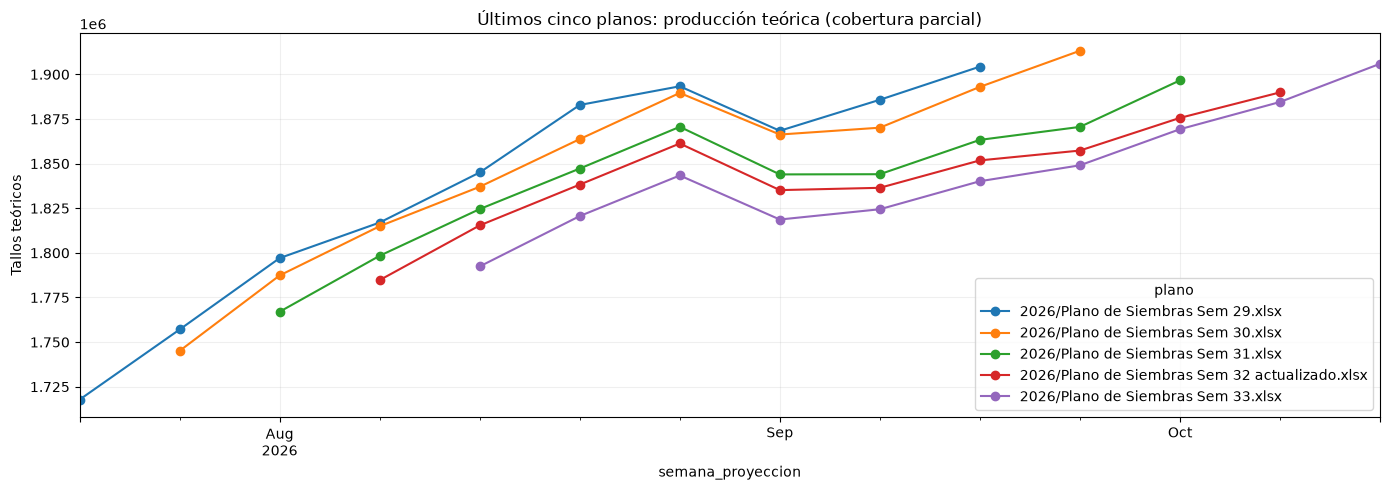

semana_plano,32,33,diferencia_33_menos_32,cambio_pct
semana_proyeccion,,,,
2026-08-17,1.815388e+06,1.792408e+06,-22979.955395,-1.265843
2026-08-24,1.838242e+06,1.820620e+06,-17622.101671,-0.958639
2026-08-31,1.861271e+06,1.843358e+06,-17912.886219,-0.962401
2026-09-07,1.835159e+06,1.818685e+06,-16474.444724,-0.897712
2026-09-14,1.836446e+06,1.824435e+06,-12010.459435,-0.654006
2026-09-21,1.851804e+06,1.840138e+06,-11666.258677,-0.629994
2026-09-28,1.857316e+06,1.849052e+06,-8263.540868,-0.444919
2026-10-05,1.875613e+06,1.869277e+06,-6335.685553,-0.337793
2026-10-12,1.889902e+06,1.884516e+06,-5385.161536,-0.284944


In [14]:
seleccionada=proyeccion_semanal.loc[proyeccion_semanal.version_seleccionada].copy()
fechas_ultimas=seleccionada.fecha_plano.drop_duplicates().nlargest(5)
comparacion_5=seleccionada.loc[seleccionada.fecha_plano.isin(fechas_ultimas)].copy()
assert comparacion_5.plano.nunique()==5
tabla_5=comparacion_5.pivot(index='semana_proyeccion',columns='plano',values='produccion_teorica')
comunes_5=tabla_5.dropna()
display(comparacion_5[['plano','semana_proyeccion','horizonte','produccion_teorica','pct_plantas_proyectadas','produccion_parcial']])
display(comunes_5)
tabla_5.plot(figsize=(14,5),marker='o',title='Últimos cinco planos: producción teórica (cobertura parcial)')
plt.ylabel('Tallos teóricos'); plt.grid(alpha=.2); plt.tight_layout(); plt.show()
anio_ultimo=int(seleccionada.anio_plano.max())
comparacion_32_33=seleccionada.loc[seleccionada.anio_plano.eq(anio_ultimo)&seleccionada.semana_plano.isin([32,33])]
tabla_32_33=comparacion_32_33.pivot(index='semana_proyeccion',columns='semana_plano',values='produccion_teorica').dropna()
if {32,33}.issubset(tabla_32_33.columns):
    tabla_32_33['diferencia_33_menos_32']=tabla_32_33[33]-tabla_32_33[32]
    tabla_32_33['cambio_pct']=100*tabla_32_33.diferencia_33_menos_32/tabla_32_33[32].replace(0,np.nan)
display(tabla_32_33)
with pd.ExcelWriter(SALIDA/'comparacion_ultimos_5_planos.xlsx') as writer:
    comparacion_5.to_excel(writer,sheet_name='Cinco_planos_y_cobertura',index=False)
    comunes_5.to_excel(writer,sheet_name='Semanas_comunes')
    tabla_32_33.to_excel(writer,sheet_name='Comparacion_32_33')

## Insumo para la base analítica y el modelo

Una fila corresponde a serie comercial, plano y semana objetivo. Se incorpora la referencia AL1 ya validada por la limpieza oficial de planos, únicamente para fechar disponibilidad supuesta: máximo entre cierre nominal y día posterior a AL1. No se recalculan curvas ni proyecciones. Publicación real pendiente de confirmación. Desde este archivo, los notebooks 10–12 sólo utilizan proyecciones, producción y clima.

In [15]:
from pathlib import Path
import pandas as pd
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Datos').is_dir())
SALIDA=ROOT/'Notebooks'/'Proyecciones Teoricas Propias'/'resultados_todos_los_anios'
# Esta lectura sólo incorpora metadatos de disponibilidad al insumo ya calculado.
# El modelo posterior no lee planos, curvas ni el panel analítico anterior.
refs=pd.read_parquet(ROOT/'Datos_analiticos_proyecto'/'planos_siembra_limpio.parquet',columns=['archivo_origen','fecha_referencia_edad'])
refs['plano']=refs.archivo_origen.str.replace('\\','/',regex=False).str.split('Plano de Siembras/').str[-1]
refs=refs.groupby('plano',as_index=False).fecha_referencia_edad.max()
q=pd.read_parquet(SALIDA/'proyecciones_semanales_modelo.parquet').drop(columns=['disponible'],errors='ignore')
q=q.merge(refs,on='plano',how='left',validate='many_to_one')
q['disponible']=pd.concat([q.fecha_plano+pd.Timedelta(days=7),q.fecha_referencia_edad+pd.Timedelta(days=1)],axis=1).max(axis=1)
q.loc[q.fecha_referencia_edad.isna(),'disponible']=pd.NaT
q=q.drop(columns='fecha_referencia_edad')
assert not q.duplicated(['plano','finca','producto','color','variedad','semana_proyeccion']).any()
q.to_parquet(SALIDA/'proyecciones_semanales_modelo.parquet',index=False)
display(q[['plano','fecha_plano','disponible']].drop_duplicates().tail(8))
print('Insumo único para el nuevo flujo:',len(q),'filas;',q.plano.nunique(),'planos; sin disponibilidad:',q.loc[q.disponible.isna(),'plano'].nunique())


,plano,fecha_plano,disponible
721060,2026/Plano de Siembras Sem 26.xlsx,2026-06-22,2026-07-07
723870,2026/Plano de Siembras Sem 27.xlsx,2026-06-29,2026-07-14
726480,2026/Plano de Siembras Sem 28.xlsx,2026-07-06,2026-07-21
729080,2026/Plano de Siembras Sem 29.xlsx,2026-07-13,2026-07-28
731700,2026/Plano de Siembras Sem 30.xlsx,2026-07-20,2026-08-04
734320,2026/Plano de Siembras Sem 31.xlsx,2026-07-27,2026-08-11
736940,2026/Plano de Siembras Sem 32 actualizado.xlsx,2026-08-03,2026-08-11
739560,2026/Plano de Siembras Sem 33.xlsx,2026-08-10,2026-08-20


Insumo único para el nuevo flujo: 742140 filas; 292 planos; sin disponibilidad: 1
